**Ответ:** CategoryPriceDistance, температура **0.1**, SVDRanker(**256** компонент, 7 итераций, seed 42). На трёх новых реализациях по 2000 пользователей test NDCG@10 ≈ **0.494**, Recall@10 ≈ **0.372**. Это модель узких однокатегорийных интересов с повторными покупками; качество на реальных людях не измерено.

**Подготовка:** исходный полный `data/olist-stream/batches/batch_000.csv`, 41 387 позиций, 14 314 товаров. Существующая очистка Olist описана в `../../datasets/model-selection/dataset_evidence.md`. Из корня: `uv run --locked python notebooks/model-selection/prepare_data.py`, затем `refine.py` и `finalize.py` тем же способом. Дорогая генерация и обучение выполняются отдельно; этот notebook читает только подготовленные CSV.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import display
HERE = Path.cwd()
required = ['validation.csv', 'quality.csv', 'refinement.csv', 'final_metrics.csv', 'final_quality.csv', 'test_per_user.csv', 'novelty.csv', 'selection.json']
missing = [name for name in required if not (HERE / name).exists()]
if missing:
    raise FileNotFoundError(f'{missing}: run prepare_data.py, refine.py, finalize.py first')
validation = pd.read_csv(HERE / 'validation.csv')
quality = pd.read_csv(HERE / 'quality.csv')
refinement = pd.read_csv(HERE / 'refinement.csv')
metrics = pd.read_csv(HERE / 'final_metrics.csv')
final_quality = pd.read_csv(HERE / 'final_quality.csv')
per_user = pd.read_csv(HERE / 'test_per_user.csv')
novelty = pd.read_csv(HERE / 'novelty.csv')
selection = json.loads((HERE / 'selection.json').read_text())
assert len(validation) == 297 and len(refinement) == 36 and len(metrics) == 33
assert not validation.duplicated(['distance', 'seed', 'model']).any()
assert not refinement.duplicated(['distance', 'seed', 'model']).any()
assert not metrics.duplicated(['distance', 'seed', 'model', 'split']).any()
for frame in (validation, refinement, metrics, quality, final_quality):
    assert not frame.isna().any().any()
    assert np.isfinite(frame.select_dtypes('number')).all().all()
def style():
    plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 11,
                         "axes.spines.top": False, "axes.spines.right": False,
                         "figure.facecolor": "white", "axes.facecolor": "white"})


**Протокол:** 70/15/15 iid событий на пользователя; train-only user/item counts; полный каталог и бинарная relevance по уникальным held-out товарам. Метрики — macro-average по пользователям. Повторы разрешены между split. Одинаковые anchors между генераторами при одном seed, но разные задачи оценки.

In [2]:
quality['passes'] = ((quality.unique_train_median >= 30) & (quality.unique_train_p10 >= 10) & (quality.mean_top_product_share <= .2) & (quality.category_tvd <= .1))
display(quality.groupby('distance').agg(median_unique=('unique_train_median', 'mean'), p10_unique=('unique_train_p10', 'mean'), top_product_share=('mean_top_product_share', 'mean'), catalog_coverage=('train_catalog_coverage', 'mean'), category_tvd=('category_tvd', 'mean'), all_seeds_pass=('passes', 'all')).round(4))

,median_unique,p10_unique,top_product_share,catalog_coverage,category_tvd,all_seeds_pass
distance,,,,,,
category,60.0000,48.6333,0.0616,0.8815,0.0511,True
category_price_t0.1,39.3333,20.3000,0.1718,0.8122,0.0525,True
category_price_t0.2,51.0000,34.0000,0.1157,0.8453,0.0496,True
category_price_t0.4,65.0000,58.0000,0.0516,0.8664,0.0503,True
category_price_time_t0.2,31.3333,15.3333,0.2347,0.6949,0.0500,False
category_price_time_t0.4,59.0000,46.0000,0.0837,0.8453,0.0501,True
timestamp_0.125d,42.0000,31.0000,0.0867,0.7660,0.0128,True
timestamp_0.5d,57.3333,50.0000,0.0522,0.8496,0.0072,True
timestamp_1d,62.0000,56.9667,0.0429,0.8667,0.0081,True


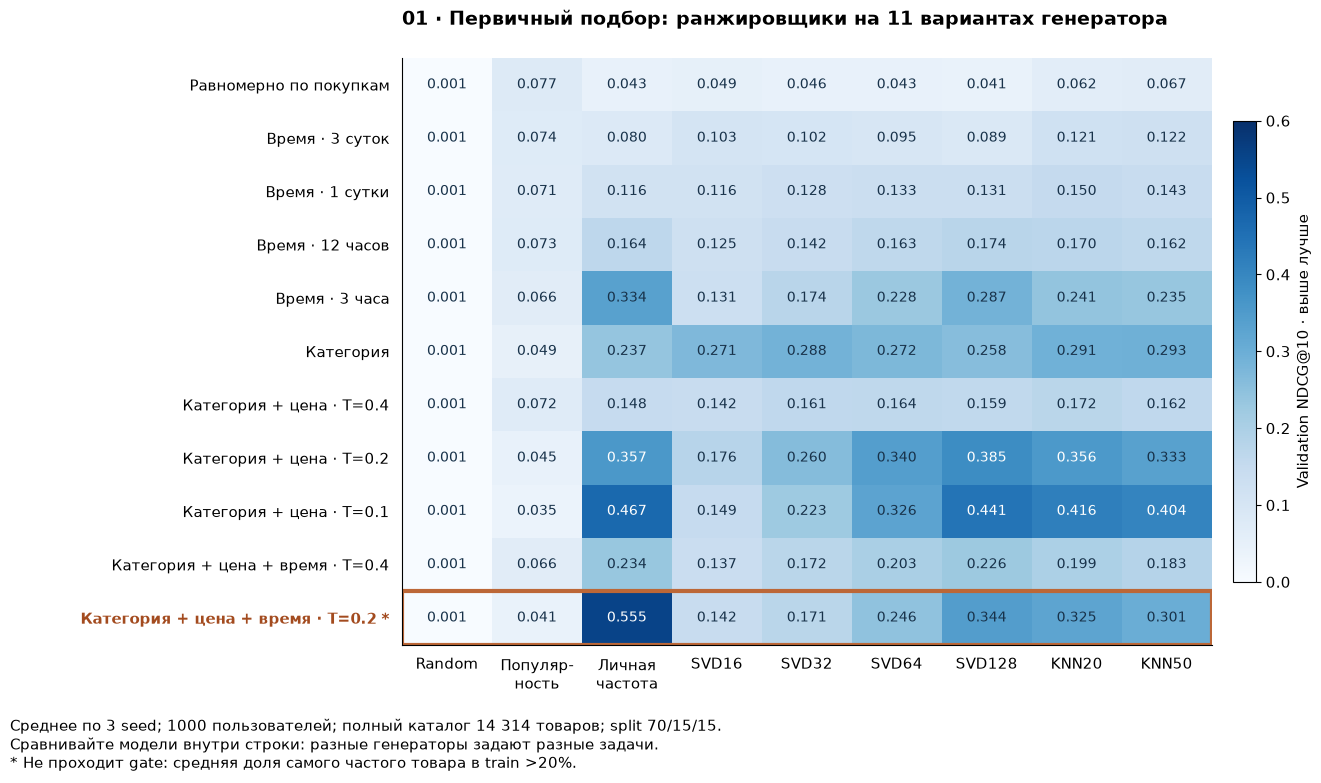

In [3]:
# Figure 01: screening
def screening_plot(validation):
    style()
    distances = ["uniform", "timestamp_3d", "timestamp_1d", "timestamp_0.5d",
                 "timestamp_0.125d", "category", "category_price_t0.4",
                 "category_price_t0.2", "category_price_t0.1",
                 "category_price_time_t0.4", "category_price_time_t0.2"]
    labels = ["Равномерно по покупкам", "Время · 3 суток", "Время · 1 сутки",
              "Время · 12 часов", "Время · 3 часа", "Категория",
              "Категория + цена · T=0.4", "Категория + цена · T=0.2",
              "Категория + цена · T=0.1", "Категория + цена + время · T=0.4",
              "Категория + цена + время · T=0.2 *"]
    models = ["random", "popularity", "personal_frequency", "svd_16", "svd_32",
              "svd_64", "svd_128", "user_knn_20", "user_knn_50"]
    table = validation.pivot_table(index="distance", columns="model", values="ndcg_at_k").loc[distances, models]
    fig, ax = plt.subplots(figsize=(14, 8.5))
    image = ax.imshow(table, vmin=0, vmax=.6, cmap="Blues", aspect="auto")
    ax.set_yticks(range(len(labels)), labels)
    ax.set_xticks(range(len(models)), ["Random", "Популяр-\nность", "Личная\nчастота", "SVD16", "SVD32",
                                      "SVD64", "SVD128", "KNN20", "KNN50"])
    ax.tick_params(length=0, pad=9)
    for row in range(len(distances)):
        for column in range(len(models)):
            value = table.iloc[row, column]
            ax.text(column, row, f"{value:.3f}", ha="center", va="center",
                    color="white" if value > .35 else "#18324a", fontsize=10)
    ax.add_patch(Rectangle((-.5, len(distances) - 1.5), len(models), 1,
                           fill=False, edgecolor="#bc6737", linewidth=3))
    ax.get_yticklabels()[-1].set_color("#a34b1f")
    ax.get_yticklabels()[-1].set_fontweight("bold")
    ax.set_title("01 · Первичный подбор: ранжировщики на 11 вариантах генератора",
                 loc="left", pad=24, fontsize=14, fontweight="bold")
    fig.colorbar(image, ax=ax, fraction=.027, pad=.025, label="Validation NDCG@10 · выше лучше")
    fig.subplots_adjust(left=.31, bottom=.20, right=.92, top=.89)
    fig.text(.03, .055, "Среднее по 3 seed; 1000 пользователей; полный каталог 14 314 товаров; split 70/15/15.\n"
             "Сравнивайте модели внутри строки: разные генераторы задают разные задачи.\n"
             "* Не проходит gate: средняя доля самого частого товара в train >20%.", fontsize=11)
    return fig

screening_plot(validation);
plt.show()

**Следующая проверка:** SVD128 на T=.1 уступил личной частоте. Поэтому до открытия test увеличили размерность и добавили T=.15. Пороги разнообразия были заданы до первичного screening; они определяют учебную пригодность, не реалистичность.

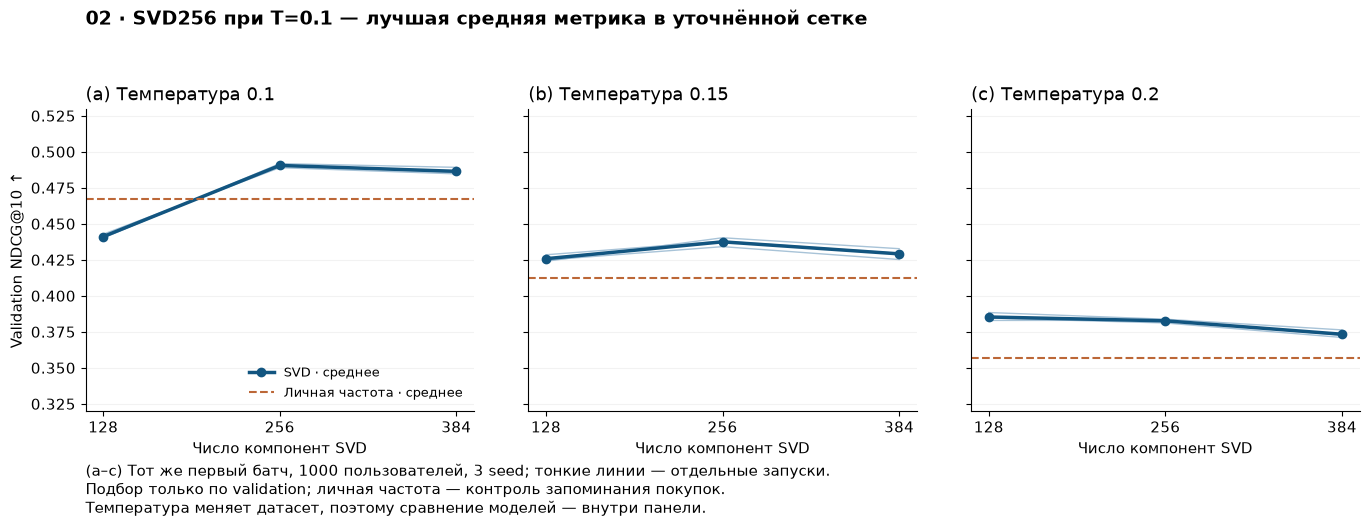

In [4]:
# Figure 02: refinement
def refinement_plot(refinement):
    style()
    fig, axes = plt.subplots(1, 3, figsize=(14, 5.5), sharey=True)
    for index, (ax, temperature) in enumerate(zip(axes, (.1, .15, .2))):
        data = refinement[refinement.distance.eq(f"category_price_t{temperature}")]
        for seed, group in data[data.model.str.startswith("svd_")].groupby("seed"):
            ranks = group.model.str.removeprefix("svd_").astype(int)
            ax.plot(ranks, group.ndcg_at_k, color="#92b4ce", linewidth=1, alpha=.8)
        means = data.groupby("model").ndcg_at_k.mean()
        ax.plot([128, 256, 384], [means[f"svd_{n}"] for n in (128, 256, 384)],
                "o-", color="#125580", linewidth=2.5, label="SVD · среднее")
        ax.axhline(means["personal_frequency"], color="#bc6737", linestyle="--",
                   label="Личная частота · среднее")
        ax.set_title(f"({chr(97 + index)}) Температура {temperature}", loc="left")
        ax.set_xticks([128, 256, 384])
        ax.set_xlabel("Число компонент SVD")
        ax.set_ylim(.32, .53)
        ax.grid(axis="y", alpha=.16)
    axes[0].set_ylabel("Validation NDCG@10 ↑")
    axes[0].legend(loc="lower right", fontsize=9, frameon=False)
    fig.suptitle("02 · SVD256 при T=0.1 — лучшая средняя метрика в уточнённой сетке",
                 x=.07, ha="left", fontsize=14, fontweight="bold")
    fig.subplots_adjust(left=.07, right=.98, bottom=.25, top=.80, wspace=.14)
    fig.text(.07, .065, "(a–c) Тот же первый батч, 1000 пользователей, 3 seed; тонкие линии — отдельные запуски.\n"
             "Подбор только по validation; личная частота — контроль запоминания покупок.\n"
             "Температура меняет датасет, поэтому сравнение моделей — внутри панели.", fontsize=11)
    return fig

refinement_plot(refinement);
plt.show()

In [5]:
chosen = refinement[refinement.distance.eq('category_price_t0.1')]
paired_validation = chosen.pivot(index='seed', columns='model', values='ndcg_at_k')
display(paired_validation.assign(svd256_minus_frequency=paired_validation.svd_256 - paired_validation.personal_frequency).round(5))
assert ((paired_validation.svd_256 - paired_validation.personal_frequency) > 0).all()
display(selection)

model,personal_frequency,svd_128,svd_256,svd_384,svd256_minus_frequency
seed,,,,,
42,0.46726,0.44275,0.48896,0.48466,0.02170
137,0.46813,0.44014,0.49177,0.48919,0.02364
2026,0.46599,0.44034,0.49078,0.48542,0.02479


{'distance_class': 'buy_today.clustering.distances.CategoryPriceDistance',
 'distance_formula': '1[category_a != category_b] + abs(log(price_a) - log(price_b))',
 'temperature': 0.1,
 'ranker_class': 'buy_today.ranking.svd.SVDRanker',
 'ranker_parameters': {'n_components': 256, 'n_iter': 7, 'random_state': 42},
 'k': 10,
 'selection_split': 'validation',
 'selection_seeds': [42, 137, 2026],
 'selection_users': 1000,
 'validation_ndcg_mean': 0.49050060136151635,
 'validation_recall_mean': 0.3677244930994931,
 'final_seeds': [73, 211, 907],
 'final_users': 2000,
 'test_used_for_selection': False,
 'scope': 'First Olist batch; synthetic single-category, narrow-price repeat purchases'}

**Фиксация:** параметры сохранены в `selection.json` до финальной оценки. Новые seeds — 73/211/907, по 2000 пользователей, каждый с собственными train/test. Модель заново обучается только на train; параметры по test не меняются.

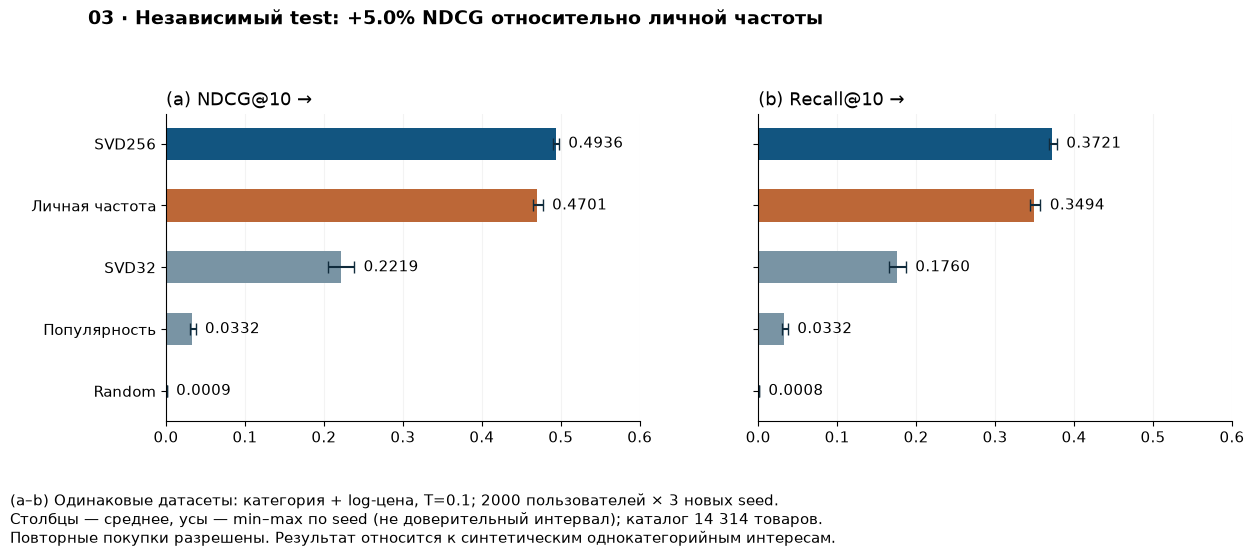

In [6]:
# Figure 03: final-test
def final_plot(metrics):
    style()
    data = metrics[metrics.split.eq("test") & metrics.distance.eq("category_price_t0.1")]
    models = ["svd_256", "personal_frequency", "svd_32", "popularity", "random"]
    labels = ["SVD256", "Личная частота", "SVD32", "Популярность", "Random"]
    colors = ["#125580", "#bc6737", "#7994a4", "#7994a4", "#7994a4"]
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.8), sharey=True)
    for ax, metric, title in zip(axes, ("ndcg_at_k", "recall_at_k"), ("(a) NDCG@10 →", "(b) Recall@10 →")):
        stats = data.groupby("model")[metric].agg(["mean", "min", "max"]).loc[models]
        y = np.arange(len(models))
        ax.barh(y, stats["mean"], color=colors, height=.52)
        ax.errorbar(stats["mean"], y,
                    xerr=np.vstack([stats["mean"] - stats["min"], stats["max"] - stats["mean"]]),
                    fmt="none", ecolor="#102b3c", capsize=4, linewidth=1.5)
        for position, value in enumerate(stats["mean"]):
            ax.text(stats["max"].iloc[position] + .012, position, f"{value:.4f}", va="center")
        ax.set_xlim(0, .60)
        ax.set_yticks(y, labels)
        ax.set_title(title, loc="left")
        ax.grid(axis="x", alpha=.15)
        ax.set_axisbelow(True)
    axes[0].invert_yaxis()
    fig.suptitle("03 · Независимый test: +5.0% NDCG относительно личной частоты",
                 x=.10, ha="left", fontsize=14, fontweight="bold")
    fig.subplots_adjust(left=.16, right=.98, bottom=.27, top=.80, wspace=.25)
    fig.text(.04, .06, "(a–b) Одинаковые датасеты: категория + log-цена, T=0.1; 2000 пользователей × 3 новых seed.\n"
             "Столбцы — среднее, усы — min–max по seed (не доверительный интервал); каталог 14 314 товаров.\n"
             "Повторные покупки разрешены. Результат относится к синтетическим однокатегорийным интересам.", fontsize=11)
    return fig

final_plot(metrics);
plt.show()

In [7]:
test = metrics[metrics.split.eq('test')]
display(test.groupby(['distance', 'model'])[['ndcg_at_k', 'recall_at_k']].agg(['mean', 'min', 'max']).round(5))
display(final_quality.round(4))
assert (final_quality.unique_train_median >= 30).all()
assert (final_quality.unique_train_p10 >= 10).all()
assert (final_quality.mean_top_product_share <= .2).all()
assert (final_quality.category_tvd <= .1).all()

ndcg_at_k                    \
                                            mean      min      max   
distance            model                                            
category_price_t0.1 personal_frequency   0.47012  0.46513  0.47704   
                    popularity           0.03316  0.02977  0.03737   
                    random               0.00086  0.00082  0.00089   
                    svd_256              0.49359  0.49064  0.49757   
                    svd_32               0.22187  0.20490  0.23829   
timestamp_1d        svd_32               0.12643  0.12303  0.13006   

                                       recall_at_k                    
                                              mean      min      max  
distance            model                                             
category_price_t0.1 personal_frequency     0.34941  0.34403  0.35738  
                    popularity             0.03319  0.02963  0.03755  
                    random                 0.00078  0.00067  0.00094  
                    svd_256                0.37208  0.36775  0.37823  
                    svd_32                 0.17598  0.16504  0.18697  
timestamp_1d        svd_32                 0.07529  0.07414  0.07672

,seed,n_source_rows,n_catalog,n_users,unique_train_median,unique_train_p10,mean_top_product_share,train_catalog_coverage,category_tvd,same_category_share
0,73,41387,14314,2000,40.0,20.0,0.1702,0.9417,0.0439,0.9992
1,211,41387,14314,2000,39.0,20.0,0.1748,0.9469,0.0333,0.9993
2,907,41387,14314,2000,40.0,20.0,0.1665,0.9465,0.0277,0.9991


**Контроль выигрыша:** парный bootstrap по пользователям отдельно внутри каждого seed, затем равновесное среднее по seeds. Это условный 95% интервал для данных трёх фиксированных обученных моделей, не интервал обобщения на Olist или на все seeds.

In [8]:
paired = per_user.pivot(index=['seed', 'user_id'], columns='model', values='ndcg_at_k')
delta = paired.svd_256 - paired.personal_frequency
rng = np.random.default_rng(20260923)
resampled = np.zeros(2000)
for seed, values in delta.groupby(level='seed'):
    values = values.to_numpy()
    resampled += values[rng.integers(len(values), size=(2000, len(values)))].mean(axis=1) / 3
display(pd.Series({'delta_ndcg': delta.mean(), 'ci_low': np.quantile(resampled, .025), 'ci_high': np.quantile(resampled, .975)}).round(5))
display(delta.groupby(level='seed').mean().rename('paired_delta_ndcg').round(5))

delta_ndcg    0.02347
ci_low        0.02076
ci_high       0.02619
dtype: float64

seed
73     0.02551
211    0.02053
907    0.02436
Name: paired_delta_ndcg, dtype: float64

**Повторение или новые товары?** Дополнительный Recall@10 считается только по held-out товарам, которых пользователь не покупал в train. Пользователи без таких товаров исключены только из этой дополнительной метрики.

In [9]:
display(novelty.groupby('model').agg(mean_relevant=('n_relevant', 'mean'), mean_novel_relevant=('n_novel_relevant', 'mean'), mean_novel_hits=('novel_hits', 'mean'), mean_seen_hits=('seen_hits', 'mean'), novel_recall=('novel_recall', 'mean'), users_with_novel=('novel_recall', 'count')).round(5))

,mean_relevant,mean_novel_relevant,mean_novel_hits,mean_seen_hits,novel_recall,users_with_novel
model,,,,,,
personal_frequency,11.6135,5.51183,0.00000,3.63000,0.00000,5766
svd_256,11.6135,5.51183,0.31117,3.58383,0.06045,5766


**Итог:** связка даёт стабильный выигрыш над личной частотой и проходит выбранные пороги разнообразия. Однако около 99.9% покупок в категории якоря; большинство попаданий — повторы. Novel recall ≈6.0%. Для многокатегорийных корзин, поздних батчей и реальных пользователей нужна отдельная проверка. Разница с текущим pipeline (время 1d + SVD32) смешивает изменение данных и модели.

**Артефакты:** `../../models/model-selection/distance.joblib`; `../../models/model-selection/seed_73/ranking/`; `../../data/model-selection/seed_73/`. Команды использования — `../../docs/model-selection.md`. Все три рисунка приведены в порядке исследования; контекст — `../../visualizations/model-selection/data_context.md`.